In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    
    # Tick direction and appearance
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,            # show top ticks
    'ytick.right': True,          # show right ticks
    'xtick.minor.visible': True,  # show minor x ticks
    'ytick.minor.visible': True,  # show minor y ticks
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    
    # Axes and line properties
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
# Pandas configuration
pd.set_option('display.max_columns', None)

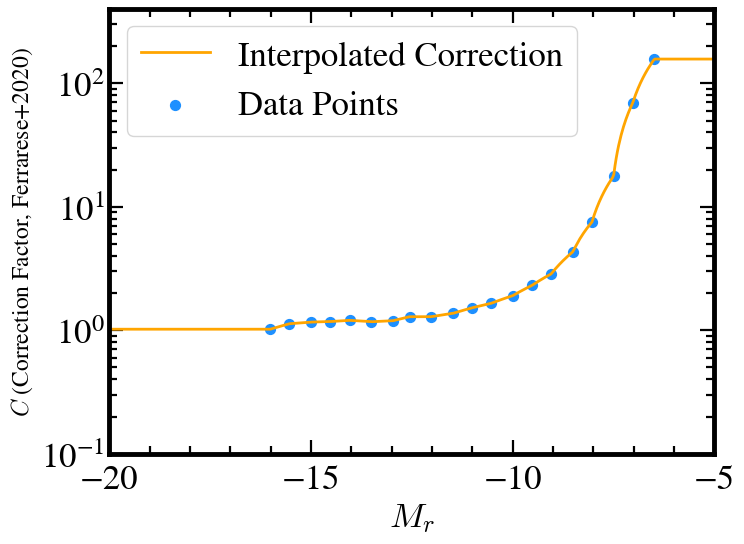

In [2]:
Z_CLID = 0.003

# Load correction factors
cordf = pd.read_csv('../../DATA/Ferrarese2020correctionFactor.csv')
cordf['CorrectionFactor'] = 100 / cordf['Completeness']

def C_photcor(mag):
    """
    Return correction factor for given M_r using linear interpolation
    of Ferrarese+2020 correction table.
    """
    mag = float(mag)
    sorted_df = cordf.sort_values('M_r').reset_index(drop=True)
    x_min, x_max = sorted_df['M_r'].iloc[0], sorted_df['M_r'].iloc[-1]

    # Clamp at boundaries
    if mag <= x_min:
        return sorted_df['CorrectionFactor'].iloc[0]
    if mag >= x_max:
        return sorted_df['CorrectionFactor'].iloc[-1]

    # Return exact match if exists
    row_match = sorted_df[sorted_df['M_r'] == mag]
    if not row_match.empty:
        return row_match['CorrectionFactor'].values[0]

    # Linear interpolation
    lower = sorted_df[sorted_df['M_r'] < mag].iloc[-1]
    upper = sorted_df[sorted_df['M_r'] > mag].iloc[0]
    x0, y0 = lower['M_r'], lower['CorrectionFactor']
    x1, y1 = upper['M_r'], upper['CorrectionFactor']
    return y0 + (y1 - y0) * (mag - x0) / (x1 - x0)

# Plot the correction factor interpolation
import numpy as np
import matplotlib.pyplot as plt

x_range = np.linspace(-20, -5, 500)
y_interp = [C_photcor(x) for x in x_range]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_range, y_interp, color='orange', label='Interpolated Correction')
ax.scatter(cordf['M_r'], cordf['CorrectionFactor'], color='dodgerblue', s=50, label='Data Points')
ax.set_xlabel('$M_r$')
ax.set_ylabel(r'$C$ (Correction Factor, Ferrarese+2020)', fontsize=17)
ax.set_xlim([-20, -5])
ax.set_ylim([0.1, 400])
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import emcee

# Load data and select bona fide members
df = pd.read_csv('../../DATA/Virgo/Virgo_core_mastercat.csv')
df_plot = df[df['Class'] != 2].copy()
df_plot['weight'] = df_plot['p_mag_r_absmag'].apply(C_photcor)

# Schechter function definition
def schechter_1D_LF(M, phi_0, M_star, alpha):
    """Schechter luminosity function in magnitude space."""
    x = 10 ** (0.4 * (M_star - M))
    return phi_0 * x ** (1 + alpha) * np.exp(-x)

# Log-likelihood function
def log_likelihood(theta, M, y, yerr):
    phi_0, M_star, alpha = theta
    model = schechter_1D_LF(M, phi_0, M_star, alpha)
    sigma2 = yerr ** 2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(2 * np.pi * sigma2))

# Uniform prior for parameters
def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 100 and -32 < M_star < -14 and -3 < alpha < 0:
        return 0.0
    return -np.inf

# Posterior probability
def log_probability(theta, M, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, y, yerr)

# Cosmological calculations
h = cosmo.H0.value / 100.0
z = Z_CLID
comoving_dist = cosmo.comoving_distance(z)
theta_arcmin = 90 * u.arcmin
transverse_dist = comoving_dist * (theta_arcmin.to(u.rad) / u.rad)
comoving_volume = 3 * np.pi * transverse_dist**3
volume_h3 = comoving_volume.value * h**3

# Histogram and error computation in mag bins
bin_width = 0.5
bin_edges = np.arange(-24, -12 + bin_width, bin_width)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

weights = df_plot['weight']
hist_corr, _ = np.histogram(df_plot['p_mag_r_absmag'], bins=bin_edges, weights=weights)
variance_corr, _ = np.histogram(df_plot['p_mag_r_absmag'], bins=bin_edges, weights=weights**2)
yerr_corr = np.sqrt(np.maximum(variance_corr, 0))

hist_corr_density = hist_corr / (bin_width * volume_h3)
yerr_corr_density = yerr_corr / (bin_width * volume_h3)

# Mask fit range
fit_range = (-24, -13)
in_fit = (
    (bin_centers > fit_range[0]) &
    (bin_centers < fit_range[1]) &
    (hist_corr_density > 0)
)
x_fit = bin_centers[in_fit]
y_fit = hist_corr_density[in_fit]
yerr_fit = yerr_corr_density[in_fit]

# MCMC setup
nwalkers = 500
nsteps = 5000
ndim = 3
initial = np.array([0.5, -21.35, -1.24])
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

# Run MCMC
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x_fit, y_fit, yerr_fit))
print(f"Running MCMC with {nwalkers} walkers for {nsteps} steps...")
sampler.run_mcmc(pos, nsteps, progress=True)

# Analyze posterior samples
samples = sampler.get_chain(discard=1000, thin=15, flat=True)
phi0_lo, phi0_med, phi0_hi = np.percentile(samples[:, 0], [16, 50, 84])
mstar_lo, mstar_med, mstar_hi = np.percentile(samples[:, 1], [16, 50, 84])
alpha_lo, alpha_med, alpha_hi = np.percentile(samples[:, 2], [16, 50, 84])

phi0_err = [phi0_med - phi0_lo, phi0_hi - phi0_med]
M_star_err = [mstar_med - mstar_lo, mstar_hi - mstar_med]
alpha_err = [alpha_med - alpha_lo, alpha_hi - alpha_med]


Running MCMC with 500 walkers for 5000 steps...


100%|██████████| 5000/5000 [00:30<00:00, 164.30it/s]


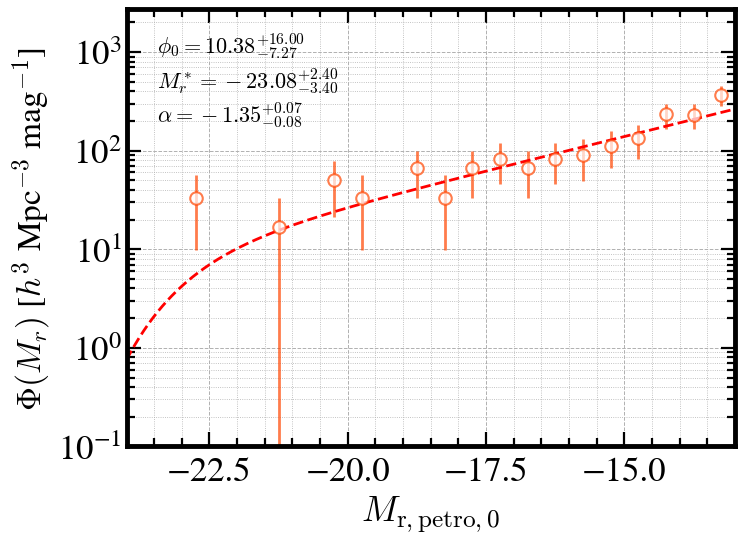

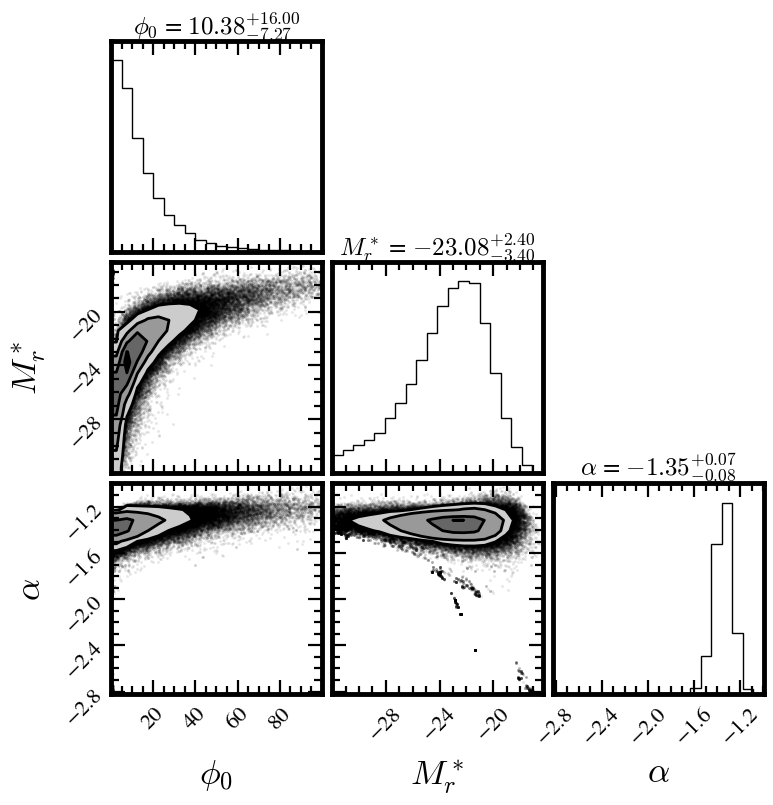

In [10]:

# --- Plotting the Result ---
fig, ax = plt.subplots(figsize=(8, 6))

# Shade regions outside the fit range
ax.axvspan(-24, fit_range[0], color='gray', alpha=0.7)
ax.axvspan(fit_range[1], -13, color='gray', alpha=0.7)

# Plot data points with errors (only where density > 0)
mask_positive = hist_corr_density > 0
ax.errorbar(
    bin_centers[mask_positive], hist_corr_density[mask_positive],
    yerr=yerr_corr_density[mask_positive],
    fmt='o', color='orangered', ecolor='orangered',
    markerfacecolor='white', markeredgewidth=1.5,
    capsize=0, alpha=0.7, markersize=9
)

# Plot best-fit Schechter function
x_model = np.linspace(-24, -12, 1000)
y_model = schechter_1D_LF(x_model, phi0_med, mstar_med, alpha_med)
ax.plot(x_model, y_model, color='red', linestyle='--', lw=2.0)

# Axis scaling/labels
ax.set_yscale('log')
ax.set_xlim(-24, -13)
ax.set_ylim(1e-1, hist_corr_density.max() * 5)
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=26)
ax.set_ylabel(r'$\Phi(M_r)$ [$h^3$ Mpc$^{-3}$ mag$^{-1}$]', fontsize=24)

# Ticks and grid
ax.grid(True, which='major', linestyle='--', linewidth=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.6)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Annotate with fit parameters and errors
annot = (
    r"$\phi_0 = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(phi0_med, phi0_err[1], phi0_err[0]) + "\n" +
    r"$M^*_r = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(mstar_med, M_star_err[1], M_star_err[0]) + "\n" +
    r"$\alpha = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(alpha_med, alpha_err[1], alpha_err[0])
)
ax.text(
    0.05, 0.95, annot, transform=ax.transAxes,
    fontsize=16, verticalalignment='top', horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8)
)

plt.tight_layout()
plt.show()

# --- Save fitted LF points below completeness limit ---
spec_comp_limit = 0  # Only retain values with M_r < spec_comp_limit
save_mask = x_fit < spec_comp_limit
df_save = pd.DataFrame({
    'M_r': x_fit[save_mask],
    'Phi': y_fit[save_mask],
    'Phi_err': yerr_fit[save_mask]
})
df_save.to_csv('Virgo_LF.csv', index=False)

# --- Plot MCMC Posterior Corners ---
import corner

labels = [r"$\phi_0$", r"$M^*_r$", r"$\alpha$"]
fig = corner.corner(
    samples,
    labels=labels,
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 18},
    plot_contours=True,
    fill_contours=True,
    fig=plt.figure(figsize=(8, 8))
)

# Use smaller tick labels
for corner_ax in fig.get_axes():
    corner_ax.tick_params(axis='both', labelsize=16)

plt.show()